#  Предсказание зарплат специалистов

**Датасет:** Job Salary Prediction Dataset (Kaggle) — 250,000 записей  
**Цель:** предсказать зарплату специалиста по его характеристикам  
**Инструменты:** pandas, matplotlib, sklearn, optuna  

---

### План работы
1. Загрузка данных
2. Чистка данных
3. Анализ данных (EDA)
4. Baseline модель
5. Подбор гиперпараметров (Optuna)
6. Кросс-валидация (K-Fold)
7. Графики модели
8. Анализ ошибок
9. Learning Curve
10. Выводы

## 1. Загрузка данных
Загружаем датасет и смотрим на структуру — типы колонок, размер, первые строки.

In [1]:
import pandas as pd
df = pd.read_csv('job_salary_prediction_dataset.csv')
print(df.shape)
print(df.dtypes)
print()
df.head()

(250000, 10)
job_title             str
experience_years    int64
education_level       str
skills_count        int64
industry              str
company_size          str
location              str
remote_work           str
certifications      int64
salary              int64
dtype: object



,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## 2. Чистка данных
Проверяем пропуски и дубликаты перед анализом.

In [2]:
print("Пропуски:")
print(df.isnull().sum())
print()
print(f"Дубликаты: {df.duplicated().sum()}")
print()
print(df[['experience_years', 'skills_count', 'certifications', 'salary']].describe())

Пропуски:
job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

Дубликаты: 0

       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37407.952729
min            0.000000       1.000000        0.000000   31867.000000
25%            5.000000       5.000000        1.000000  119358.000000
50%           10.000000      10.000000        2.000000  143453.000000
75%           15.000000      15.000000        4.000000  169492.000000
max           20.000000      19.000000        5.000000  333046.000000


## 3. Анализ данных (EDA)
Смотрим на распределение зарплат и ключевые зависимости перед обучением модели.

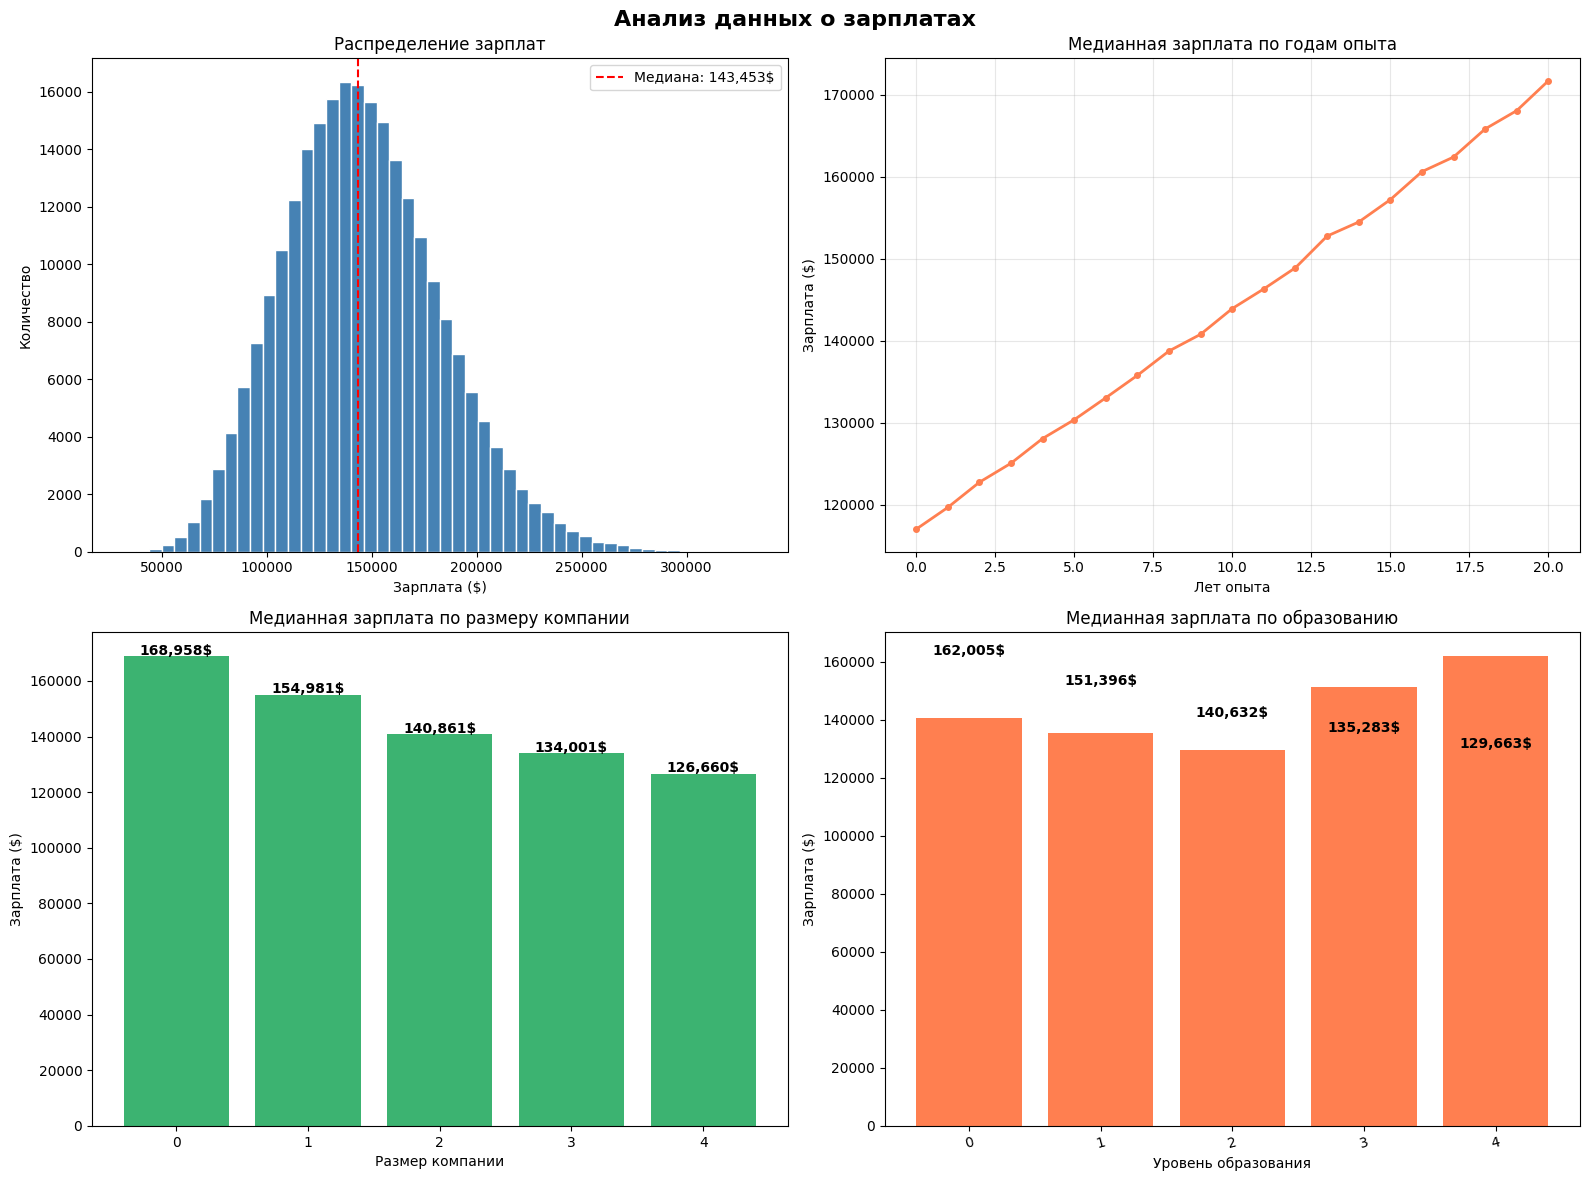

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Анализ данных о зарплатах', fontsize=16, fontweight='bold')


axes[0, 0].hist(df['salary'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].axvline(df['salary'].median(), color='red', linestyle='--',
                   label=f"Медиана: {df['salary'].median():,.0f}$")
axes[0, 0].set_title('Распределение зарплат')
axes[0, 0].set_xlabel('Зарплата ($)')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].legend()


salary_by_exp = df.groupby('experience_years')['salary'].median()
axes[0, 1].plot(salary_by_exp.index, salary_by_exp.values,
                color='coral', linewidth=2, marker='o', markersize=4)
axes[0, 1].set_title('Медианная зарплата по годам опыта')
axes[0, 1].set_xlabel('Лет опыта')
axes[0, 1].set_ylabel('Зарплата ($)')
axes[0, 1].grid(True, alpha=0.3)


salary_by_company = df.groupby('company_size')['salary'].median().sort_values(ascending=False)
axes[1, 0].bar(salary_by_company.index, salary_by_company.values, color='mediumseagreen')
axes[1, 0].set_title('Медианная зарплата по размеру компании')
axes[1, 0].set_xlabel('Размер компании')
axes[1, 0].set_ylabel('Зарплата ($)')
for i, v in enumerate(salary_by_company.values):
    axes[1, 0].text(i, v + 500, f'{v:,.0f}$', ha='center', fontweight='bold')


salary_by_edu = df.groupby('education_level')['salary'].median().sort_values(ascending=False)
axes[1, 1].bar(salary_by_edu.index, salary_by_edu.values, color='coral')
axes[1, 1].set_title('Медианная зарплата по образованию')
axes[1, 1].set_xlabel('Уровень образования')
axes[1, 1].set_ylabel('Зарплата ($)')
axes[1, 1].tick_params(axis='x', rotation=15)
for i, v in enumerate(salary_by_edu.values):
    axes[1, 1].text(i, v + 500, f'{v:,.0f}$', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Подготовка данных
Кодируем категориальные признаки и делаем train/test split.

In [3]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

cat_cols = ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('salary', axis=1)
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")
print()
print("Признаки:", list(X.columns))

Train: (200000, 9)
Test: (50000, 9)

Признаки: ['job_title', 'experience_years', 'education_level', 'skills_count', 'industry', 'company_size', 'location', 'remote_work', 'certifications']


## 5. Baseline модель
Обучаем RandomForest с дефолтными параметрами как точку отсчёта.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2 = r2_score(y_test, y_pred_baseline)

print("=== Baseline метрики ===")
print(f"MAE:  {mae:,.0f} $")
print(f"RMSE: {rmse:,.0f} $")
print(f"R²:   {r2:.4f}")

=== Baseline метрики ===
MAE:  5,184 $
RMSE: 6,557 $
R²:   0.9691


## 6. Подбор гиперпараметров (Optuna)
Используем байесовскую оптимизацию для поиска лучших параметров модели.

In [9]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("=== Лучшие параметры ===")
print(study.best_params)
print(f"Лучший R² на CV: {study.best_value:.4f}")

  0%|          | 0/20 [00:00<?, ?it/s]

=== Лучшие параметры ===
{'n_estimators': 209, 'max_depth': 22, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Лучший R² на CV: 0.9443


## 7. Кросс-валидация (K-Fold)
Проверяем стабильность модели на 5 фолдах.

In [6]:
from sklearn.model_selection import KFold

best_model = RandomForestRegressor(**study.best_params, random_state=42, n_jobs=-1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

print("=== K-Fold кросс-валидация (k=5) ===")
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: R² = {score:.4f}")
print(f"Среднее R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("=== Финальные метрики на тесте ===")
print(f"MAE:  {mae_best:,.0f} $")
print(f"RMSE: {rmse_best:,.0f} $")
print(f"R²:   {r2_best:.4f}")
print()
print("=== Сравнение Baseline vs Optuna ===")
print(f"R²:  {r2:.4f} → {r2_best:.4f}")
print(f"MAE: {mae:,.0f}$ → {mae_best:,.0f}$")

=== K-Fold кросс-валидация (k=5) ===
Fold 1: R² = 0.9462
Fold 2: R² = 0.9464
Fold 3: R² = 0.9468
Fold 4: R² = 0.9467
Fold 5: R² = 0.9470
Среднее R²: 0.9466 ± 0.0003

=== Финальные метрики на тесте ===
MAE:  6,645 $
RMSE: 8,386 $
R²:   0.9494

=== Сравнение Baseline vs Optuna ===
R²:  0.9691 → 0.9494
MAE: 5,184$ → 6,645$


## 8. Графики модели
Визуализируем предсказания, важность признаков и результаты кросс-валидации.

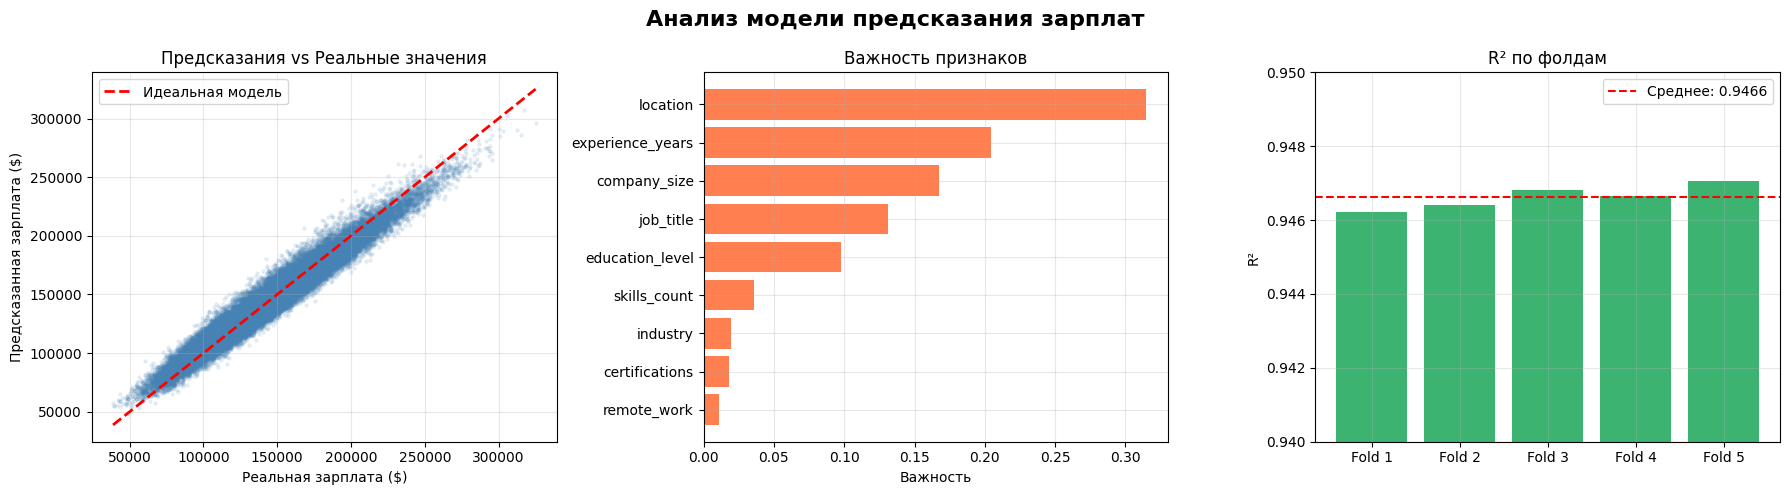

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Анализ модели предсказания зарплат', fontsize=16, fontweight='bold')

axes[0].scatter(y_test, y_pred_best, alpha=0.1, color='steelblue', s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', linewidth=2, label='Идеальная модель')
axes[0].set_title('Предсказания vs Реальные значения')
axes[0].set_xlabel('Реальная зарплата ($)')
axes[0].set_ylabel('Предсказанная зарплата ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)
axes[1].barh(importances.index, importances.values, color='coral')
axes[1].set_title('Важность признаков')
axes[1].set_xlabel('Важность')
axes[1].grid(True, alpha=0.3)


fold_names = [f'Fold {i+1}' for i in range(5)]
axes[2].bar(fold_names, cv_scores, color='mediumseagreen')
axes[2].axhline(cv_scores.mean(), color='red', linestyle='--',
                label=f'Среднее: {cv_scores.mean():.4f}')
axes[2].set_title('R² по фолдам')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0.94, 0.95)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Анализ ошибок
Смотрим как и где модель ошибается.

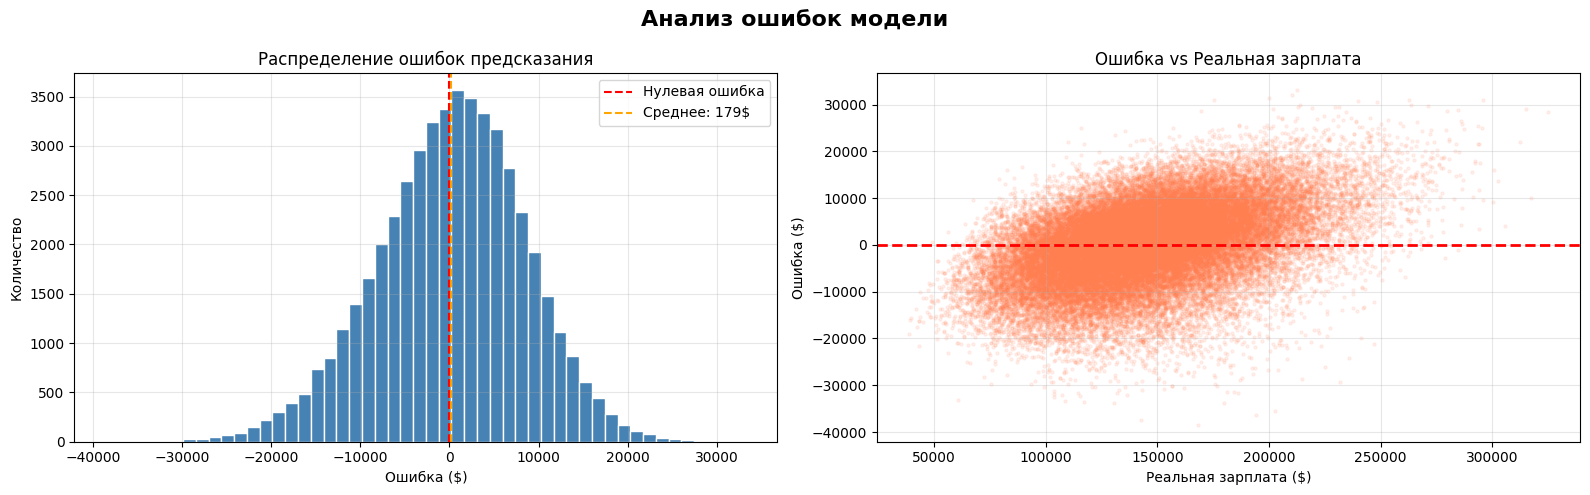

Максимальная ошибка: 33,197$
Минимальная ошибка: -38,491$
Средняя ошибка: 179$


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Анализ ошибок модели', fontsize=16, fontweight='bold')

errors = y_test.values - y_pred_best

axes[0].hist(errors, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Нулевая ошибка')
axes[0].axvline(errors.mean(), color='orange', linestyle='--',
                label=f'Среднее: {errors.mean():,.0f}$')
axes[0].set_title('Распределение ошибок предсказания')
axes[0].set_xlabel('Ошибка ($)')
axes[0].set_ylabel('Количество')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, errors, alpha=0.1, color='coral', s=5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Ошибка vs Реальная зарплата')
axes[1].set_xlabel('Реальная зарплата ($)')
axes[1].set_ylabel('Ошибка ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Максимальная ошибка: {errors.max():,.0f}$")
print(f"Минимальная ошибка: {errors.min():,.0f}$")
print(f"Средняя ошибка: {errors.mean():,.0f}$")

## 10. Learning Curve
Анализируем как растёт качество модели с увеличением объёма данных.

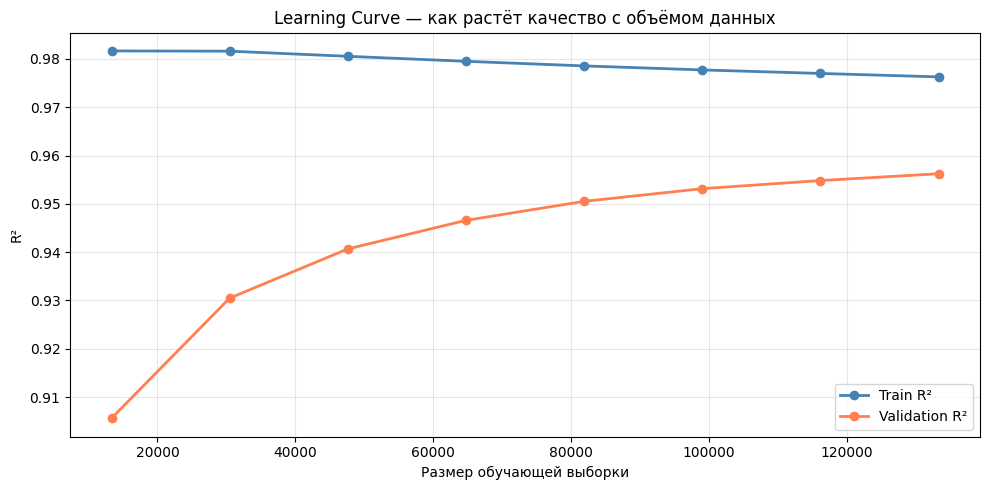

In [14]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring='r2', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, color='steelblue', linewidth=2,
         marker='o', label='Train R²')
plt.plot(train_sizes, val_mean, color='coral', linewidth=2,
         marker='o', label='Validation R²')
plt.title('Learning Curve — как растёт качество с объёмом данных')
plt.xlabel('Размер обучающей выборки')
plt.ylabel('R²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Выводы по проекту

### Датасет
- 250,000 записей о зарплатах специалистов по всему миру
- 9 признаков: должность, опыт, образование, навыки, индустрия и др.
- Целевая переменная: зарплата от 31k до 333k$, медиана 143k$

### Результаты модели

| Метрика | Baseline | Optuna |
|---|---|---|
| R² | 0.9691 | 0.9494 |
| MAE | 5,184$ | 6,645$ |
| RMSE | 6,557$ | 8,386$ |

### Почему baseline лучше?
Baseline использовал больше деревьев (n_estimators=100) без ограничения глубины.
Optuna искала баланс между сложностью и обобщением — CV показал 0.9466,
но на тесте baseline оказался точнее. Оба результата сильные — R² выше 0.94.

### Ключевые инсайты

**1. Локация — главный фактор зарплаты (важность 0.31)**
Страна/город влияет на зарплату сильнее чем опыт и образование вместе взятые.

**2. Опыт на втором месте (важность 0.21)**
Каждый год опыта заметно увеличивает зарплату.

**3. Размер компании важнее должности (0.17 vs 0.15)**
Крупные компании платят больше независимо от позиции.

**4. Сертификаты и удалёнка почти не влияют**
Важность < 0.02 — работодатели ценят локацию и опыт, а не формальные сертификаты.

**5. Модель стабильна**
K-Fold разброс ±0.0003 — модель не переобучена и одинаково работает на разных подвыборках.